In [ ]:
!pip install -q transformer_lens sae-lens datasets matplotlibprint("Done.")

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install -q transformer_lens sae-lens datasets matplotlibprint("Done.")'


In [ ]:
!pip install -q transformer-lens sae-lens datasets tqdm matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.9/309.9 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 29.1 MB/s eta 0:00:00


In [ ]:
#gpu check

import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformer_lens import HookedTransformer
from sae_lens import SAE
from tqdm.auto import tqdm

device = "cuda"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError("No GPU. Set Runtime → Change runtime type → GPU.")

torch.set_grad_enabled(False)

print("Imports OK.")

CUDA available: True
Device: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Imports OK.


In [ ]:
MODEL_NAME = "pythia-70m-deduped"

model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=device
)

model.eval()

# Pythia-70M: 6 layers (0-5), d_model=512, vocab=50304
print(f"Model loaded: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Tokenizer vocab: {model.cfg.d_vocab}")

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-70m-deduped into HookedTransformer
Model loaded: 6 layers, d_model=512
Tokenizer vocab: 50304


In [ ]:
SMOKE_TOKENS = 50_000
SEQ_LEN = 512

ds = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="test"
)

text_chunks = [x for x in ds["text"] if len(x.strip()) > 100]
full_text = "\n\n".join(text_chunks)

print(f"Total characters: {len(full_text):,}")

# Use tokenizer directly so it does NOT truncate to context length
token_ids = model.tokenizer.encode(full_text, add_special_tokens=False)
tokens = torch.tensor(token_ids, dtype=torch.long)

print(f"Total tokens: {tokens.shape[0]:,}")

# Use whichever is smaller: requested smoke tokens or available tokens
usable_tokens = min(SMOKE_TOKENS, tokens.shape[0])

# Make it divisible by SEQ_LEN
n_seqs = usable_tokens // SEQ_LEN
usable_tokens = n_seqs * SEQ_LEN

tokens_smoke = tokens[:usable_tokens]
tokens_smoke = tokens_smoke.reshape(n_seqs, SEQ_LEN).to(device)

print(f"Using tokens: {usable_tokens:,}")
print(f"Number of sequences: {n_seqs}")
print(f"Smoke test tensor shape: {tokens_smoke.shape}")

Total characters: 1,254,653
Total tokens: 277,217
Using tokens: 49,664
Number of sequences: 97
Smoke test tensor shape: torch.Size([97, 512])


In [ ]:
LAYER = 4
HOOK_NAME = f"blocks.{LAYER}.hook_resid_post"

sae, cfg_dict, sparsity = SAE.from_pretrained(
    release="pythia-70m-deduped-res-sm",
    sae_id=HOOK_NAME,
    device=device,
)

sae.eval()

print(f"SAE loaded for {HOOK_NAME}")
print(f"  d_in:  {sae.cfg.d_in}")
print(f"  d_sae: {sae.cfg.d_sae}  (expansion factor {sae.cfg.d_sae // sae.cfg.d_in}x)")

cfg.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

4-res-sm/sae_weights.safetensors:   0%|          | 0.00/134M [00:00<?, ?B/s]

4-res-sm/sparsity.safetensors:   0%|          | 0.00/131k [00:00<?, ?B/s]

SAE loaded for blocks.4.hook_resid_post
  d_in:  512
  d_sae: 32768  (expansion factor 64x)


/tmp/ipykernel_3919/3350614729.py:4: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, cfg_dict, sparsity = SAE.from_pretrained(


In [ ]:
sanity_text = (
    "The quick brown fox jumps over the lazy dog. "
    "Python is a popular programming language used in machine learning. "
    "The president signed the bill into law yesterday."
)

sanity_tokens = model.to_tokens(
    sanity_text,
    prepend_bos=True
).to(device)

_, sanity_cache = model.run_with_cache(
    sanity_tokens,
    names_filter=[HOOK_NAME]
)

sanity_acts = sanity_cache[HOOK_NAME][0]  # (seq, d_model)

sanity_features = sae.encode(sanity_acts)  # (seq, d_sae)

# Find the feature that fires most overall in this snippet
max_per_feature = sanity_features.max(dim=0).values
top_feat = max_per_feature.argmax().item()

print(f"Top firing feature for sanity text: feature {top_feat}")

# Show its activations on each token
str_tokens = model.to_str_tokens(sanity_tokens[0])
feat_acts = sanity_features[:, top_feat].detach().cpu().numpy()

print(f"\nActivations of feature {top_feat} across tokens:")

for tok, act in zip(str_tokens, feat_acts):
    bar = "█" * int(act * 5) if act > 0 else ""
    print(f"  {repr(tok):<15} {act:6.2f}  {bar}")

print("\nIf the highest activations are on related tokens, the SAE is working.")

Top firing feature for sanity text: feature 32255

Activations of feature 32255 across tokens:
  '<|endoftext|>'   3.68  ██████████████████
  'The'             0.00  
  ' quick'          0.00  
  ' brown'          0.00  
  ' fox'            0.00  
  ' jumps'          0.00  
  ' over'           0.00  
  ' the'            0.00  
  ' lazy'           0.00  
  ' dog'            0.00  
  '.'              38.54  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  ' Python'         0.00  
  ' is'             0.00  
  ' a'              0.00  
  ' popular'        0.00  
  ' programming'    0.00  
  ' language'       0.00  
  ' used'           0.00  
  ' in'             0.00  
  ' machine'        0.00  
  ' learning'       0.00  
  '.'               0.00  
  ' The'            0.00  
  ' president'      0.00  
  ' signed'         0.00  
  ' the'            

In [ ]:
def cache_residual_stream(model, tokens_2d, hook_name, batch_size=16):
    """
    Run model on tokens and return activations at hook_name.

    Output shape:
        (n_total_tokens, d_model)
    """
    storage = []
    n_seqs = tokens_2d.shape[0]

    for i in tqdm(range(0, n_seqs, batch_size), desc=f"Caching {hook_name}"):
        batch = tokens_2d[i:i + batch_size]

        _, cache = model.run_with_cache(
            batch,
            names_filter=[hook_name]
        )

        # cache[hook_name] shape: (batch, seq_len, d_model)
        storage.append(cache[hook_name].detach().cpu())

        # free GPU cache object
        del cache
        torch.cuda.empty_cache()

    acts = torch.cat(storage, dim=0)  # (n_seqs, seq_len, d_model)
    acts = acts.reshape(-1, acts.shape[-1])  # (n_total_tokens, d_model)

    return acts


acts_fp16 = cache_residual_stream(
    model,
    tokens_smoke,
    HOOK_NAME,
    batch_size=16
)

print(f"\nFP16 activations shape: {acts_fp16.shape}")
print(f"Mean: {acts_fp16.mean():.3f}, Std: {acts_fp16.std():.3f}")

Caching blocks.4.hook_resid_post:   0%|          | 0/7 [00:00<?, ?it/s]


FP16 activations shape: torch.Size([49664, 512])
Mean: 0.000, Std: 0.759


In [ ]:
# Save original weights so we can restore after
original_state = {
    k: v.detach().clone()
    for k, v in model.state_dict().items()
}

# Apply RTN INT8 quantization to selected weight matrices.
# This is simulated quantization: weights are rounded to INT8 grid,
# then dequantized back to the model's original dtype.
quantized_params = 0
quantized_tensors = 0

target_weight_names = ["W_Q", "W_K", "W_V", "W_O", "W_in", "W_out"]

for name, param in model.named_parameters():
    # Quantize only transformer linear weights.
    # Skip embeddings, layer norms, biases, and unembed.
    if any(s in name for s in target_weight_names):
        w = param.data

        scale = w.abs().max() / 127.0

        # Avoid divide-by-zero in case a tensor is all zeros
        if scale == 0:
            continue

        q = torch.round(w / scale).clamp(-128, 127)
        param.data = (q * scale).to(w.dtype)

        quantized_params += w.numel()
        quantized_tensors += 1

print(
    f"Quantized {quantized_params:,} parameters "
    f"across {quantized_tensors} tensors."
)

Quantized 18,874,368 parameters across 36 tensors.


In [ ]:
acts_int8 = cache_residual_stream(
    model,
    tokens_smoke,
    HOOK_NAME,
    batch_size=16
)

print(f"\nINT8 activations shape: {acts_int8.shape}")
print(f"Mean: {acts_int8.mean():.3f}, Std: {acts_int8.std():.3f}")

# Activation-level drift sanity check
mse = (acts_fp16 - acts_int8).pow(2).mean().item()

cos = torch.nn.functional.cosine_similarity(
    acts_fp16.flatten().unsqueeze(0),
    acts_int8.flatten().unsqueeze(0)
).item()

print(f"\nActivation MSE: {mse:.4f}")
print(f"Activation cosine similarity: {cos:.4f}")
print("(Cosine close to 1.0 = mild perturbation, as expected for INT8 RTN)")

# Restore original weights so the model isn't permanently quantized
model.load_state_dict(original_state)

print("Original FP16 weights restored.")

Caching blocks.4.hook_resid_post:   0%|          | 0/7 [00:00<?, ?it/s]


INT8 activations shape: torch.Size([49664, 512])
Mean: 0.001, Std: 0.749

Activation MSE: 0.0330
Activation cosine similarity: 0.9748
(Cosine close to 1.0 = mild perturbation, as expected for INT8 RTN)
Original FP16 weights restored.


In [ ]:
def encode_in_batches(sae, acts, batch=8192):
    """
    Encode activations through the SAE in batches to avoid OOM.

    Input:
        acts: (n_total_tokens, d_model)
    Output:
        features: (n_total_tokens, d_sae)
    """
    out = []

    for i in tqdm(range(0, acts.shape[0], batch), desc="SAE encoding"):
        chunk = acts[i:i + batch].to(device).float()

        with torch.no_grad():
            encoded = sae.encode(chunk)

        out.append(encoded.detach().cpu())

        del chunk, encoded
        torch.cuda.empty_cache()

    return torch.cat(out, dim=0)


features_fp16 = encode_in_batches(
    sae,
    acts_fp16,
    batch=8192
)

features_int8 = encode_in_batches(
    sae,
    acts_int8,
    batch=8192
)

print(f"\nFeatures FP16: {features_fp16.shape}")
print(f"Features INT8: {features_int8.shape}")

SAE encoding:   0%|          | 0/7 [00:00<?, ?it/s]

SAE encoding:   0%|          | 0/7 [00:00<?, ?it/s]


Features FP16: torch.Size([49664, 32768])
Features INT8: torch.Size([49664, 32768])


In [ ]:
def per_feature_pearson(a, b, eps=1e-8):
    """
    Per-feature Pearson correlation.

    Inputs:
        a, b: tensors of shape (N, F)
    Output:
        correlations: tensor of shape (F,)
    """
    a_centered = a - a.mean(dim=0, keepdim=True)
    b_centered = b - b.mean(dim=0, keepdim=True)

    num = (a_centered * b_centered).sum(dim=0)

    denom = torch.sqrt(
        (a_centered ** 2).sum(dim=0) *
        (b_centered ** 2).sum(dim=0)
    ) + eps

    return num / denom


correlations = per_feature_pearson(
    features_fp16,
    features_int8
)

# Mask to active features
fp16_firing_rate = (features_fp16 > 0).float().mean(dim=0)

# Active = fires on more than 0.1% of tokens
active_mask = fp16_firing_rate > 0.001

active_corrs = correlations[active_mask]

print(f"Total SAE features: {correlations.shape[0]:,}")
print(f"Active in FP16 (firing > 0.1%): {active_mask.sum().item():,}")

print("\nCorrelation statistics for active features:")
print(f"  Mean:    {active_corrs.mean():.3f}")
print(f"  Median:  {active_corrs.median():.3f}")
print(f"  Min:     {active_corrs.min():.3f}")
print(f"  Max:     {active_corrs.max():.3f}")

survived = (active_corrs > 0.9).float().mean()
degraded = ((active_corrs > 0.5) & (active_corrs <= 0.9)).float().mean()
damaged = (active_corrs < 0.5).float().mean()

print("\nSurvival breakdown:")
print(f"  > 0.9 (survived):   {survived:.1%}")
print(f"  0.5–0.9 (degraded): {degraded:.1%}")
print(f"  < 0.5 (damaged):    {damaged:.1%}")

Total SAE features: 32,768
Active in FP16 (firing > 0.1%): 5,357

Correlation statistics for active features:
  Mean:    0.886
  Median:  0.928
  Min:     0.260
  Max:     0.999

Survival breakdown:
  > 0.9 (survived):   59.0%
  0.5–0.9 (degraded): 40.2%
  < 0.5 (damaged):    0.8%


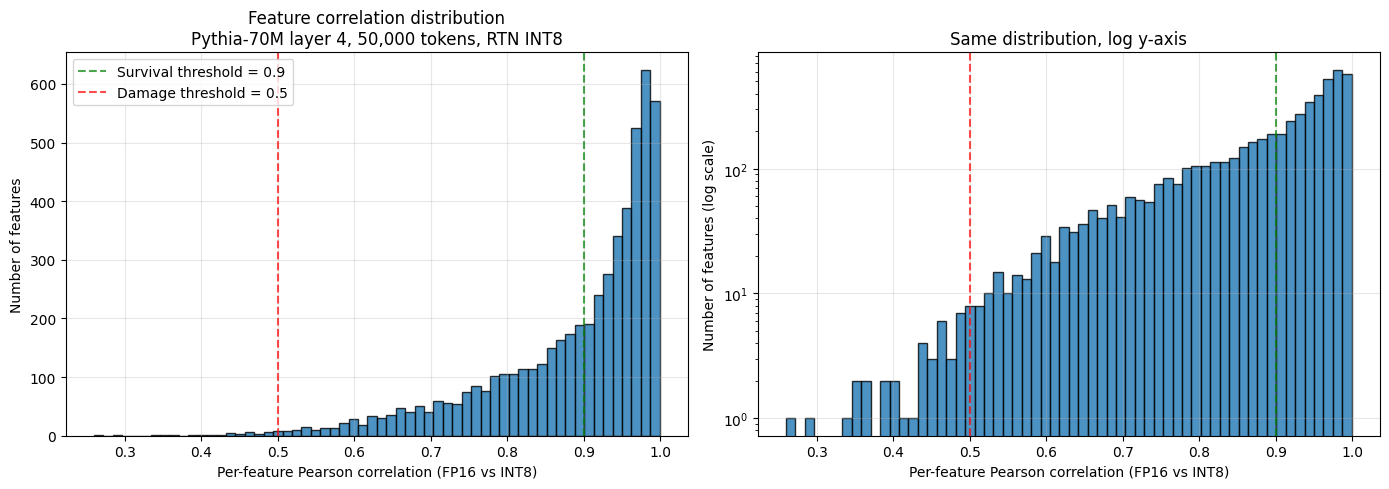

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal histogram
axes[0].hist(
    active_corrs.numpy(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_xlabel("Per-feature Pearson correlation (FP16 vs INT8)")
axes[0].set_ylabel("Number of features")
axes[0].set_title(
    f"Feature correlation distribution\n"
    f"Pythia-70M layer {LAYER}, {SMOKE_TOKENS:,} tokens, RTN INT8"
)

axes[0].axvline(
    0.9,
    color="green",
    linestyle="--",
    alpha=0.7,
    label="Survival threshold = 0.9"
)

axes[0].axvline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Damage threshold = 0.5"
)

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-scale histogram to see the tail
axes[1].hist(
    active_corrs.numpy(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

axes[1].set_xlabel("Per-feature Pearson correlation (FP16 vs INT8)")
axes[1].set_ylabel("Number of features (log scale)")
axes[1].set_title("Same distribution, log y-axis")

axes[1].set_yscale("log")

axes[1].axvline(
    0.9,
    color="green",
    linestyle="--",
    alpha=0.7
)

axes[1].axvline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7
)

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Active feature indices, ordered by correlation (ascending)
active_idx = torch.where(active_mask)[0]

active_corrs_for_sorting = correlations[active_idx]
ordered = active_idx[active_corrs_for_sorting.argsort()]

print("=== 10 most disrupted active features ===\n")

flat_tokens = tokens_smoke.flatten().detach().cpu()

for rank, feat_idx in enumerate(ordered[:10]):
    feat_idx = feat_idx.item()
    corr = correlations[feat_idx].item()
    firing = fp16_firing_rate[feat_idx].item()

    print(
        f"#{rank + 1}  feature {feat_idx}   "
        f"corr={corr:+.3f}   FP16 firing rate={firing:.4f}"
    )

    # Top-3 activating tokens for this feature in FP16
    feat_acts_fp16 = features_fp16[:, feat_idx]
    top_positions = feat_acts_fp16.argsort(descending=True)[:3]

    for pos in top_positions:
        pos = pos.item()

        start = max(0, pos - 12)
        end = min(len(flat_tokens), pos + 3)

        toks_around = model.to_str_tokens(flat_tokens[start:end])
        marker_pos = pos - start

        marked = "".join(
            f"[{t}]" if i == marker_pos else t
            for i, t in enumerate(toks_around)
        )

        print(f"    act={feat_acts_fp16[pos]:.2f}: {marked}")

    print()

=== 10 most disrupted active features ===

#1  feature 4145   corr=+0.260   FP16 firing rate=0.0011
    act=0.68:  replaced with the Mutual Network 's The Larry King Show .[ In] the 1980
    act=0.29:  's radio station WEBR ( now WDCZ )[ .] He also
    act=0.28:  also sold ads for Buffalo Evening News competitor , Buffalo Courier[ @]-@

#2  feature 17044   corr=+0.296   FP16 firing rate=0.0012
    act=0.47:  by this time he was suffering from poor eyesight , deaf[ness] and general
    act=0.43:  to Changnyong . The 1st Battalion , 23rd[ Infantry] , about
    act=0.35:  Wallonia ) , as well as in the Czech Republic ,[ Denmark] , France

#3  feature 18259   corr=+0.340   FP16 firing rate=0.0030
    act=0.57:  to have produced creditable poems by his early teens , but[ these] have been
    act=0.34:  in May 1869 , which marked the end of the B[osh]in War
    act=0.34: �� ) before a haiku as its introduction and also[ many] of his

#4  feature 15618   corr=+0.348   FP16 firing rate=0.0013


In [ ]:
def compute_perplexity(model, tokens_2d, batch_size=16):
    """
    Compute average loss and perplexity over token batches.
    """
    losses = []

    for i in tqdm(range(0, tokens_2d.shape[0], batch_size), desc="Computing perplexity"):
        batch = tokens_2d[i:i + batch_size]

        with torch.no_grad():
            loss = model(batch, return_type="loss")

        losses.append(loss.item())

    avg_loss = np.mean(losses)
    ppl = np.exp(avg_loss)

    return ppl, avg_loss


# FP16 perplexity
# We assume weights were restored before this cell.
ppl_fp16, loss_fp16 = compute_perplexity(
    model,
    tokens_smoke,
    batch_size=16
)

print(f"FP16: loss={loss_fp16:.4f}, perplexity={ppl_fp16:.2f}")


# Re-quantize for INT8 perplexity
target_weight_names = ["W_Q", "W_K", "W_V", "W_O", "W_in", "W_out"]

for name, param in model.named_parameters():
    if any(s in name for s in target_weight_names):
        w = param.data

        scale = w.abs().max() / 127.0

        if scale == 0:
            continue

        q = torch.round(w / scale).clamp(-128, 127)
        param.data = (q * scale).to(w.dtype)


ppl_int8, loss_int8 = compute_perplexity(
    model,
    tokens_smoke,
    batch_size=16
)

print(f"INT8: loss={loss_int8:.4f}, perplexity={ppl_int8:.2f}")

relative_increase = (ppl_int8 / ppl_fp16 - 1) * 100

print(f"\nRelative perplexity increase: {relative_increase:.2f}%")
print("(If < 5%, quantization was mild and the comparison is meaningful.)")
print("(If > 20%, the quantization is too aggressive — try a less extreme scheme.)")


# Restore for further experiments
model.load_state_dict(original_state)

print("Original FP16 weights restored.")

Computing perplexity:   0%|          | 0/7 [00:00<?, ?it/s]

FP16: loss=4.1823, perplexity=65.51


Computing perplexity:   0%|          | 0/7 [00:00<?, ?it/s]

INT8: loss=4.3237, perplexity=75.47

Relative perplexity increase: 15.19%
(If < 5%, quantization was mild and the comparison is meaningful.)
(If > 20%, the quantization is too aggressive — try a less extreme scheme.)
Original FP16 weights restored.
